In [1]:
import os
import torch

os.environ["UNSLOTH_COMPILE_DISABLE"] = "1"
torch._dynamo.config.disable = True

In [2]:
from unsloth import FastLanguageModel
from trl import SFTTrainer
from datasets import load_dataset
from transformers import TrainingArguments
import os
from dotenv import load_dotenv

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


[unsloth_zoo.log|WARNING]Unsloth: Could not patch trl.trainer.grpo_trainer: Direct module loading failed for UnslothGRPOTrainer: Unexpected optimization option triton.enable_persistent_tma_matmul, known options are ['TYPE_CHECKING', 'enable_auto_functionalized_v2', 'debug', 'disable_progress', 'verbose_progress', 'fx_graph_cache', 'fx_graph_remote_cache', 'autotune_local_cache', 'autotune_remote_cache', 'force_disable_caches', 'sleep_sec_TESTING_ONLY', 'custom_op_default_layout_constraint', 'cpp_wrapper', 'abi_compatible', 'c_shim_version', 'dce', 'static_weight_shapes', 'size_asserts', 'nan_asserts', 'pick_loop_orders', 'inplace_buffers', 'allow_buffer_reuse', 'memory_planning', 'memory_pool', 'benchmark_harness', 'epilogue_fusion', 'epilogue_fusion_first', 'pattern_matcher', 'b2b_gemm_pass', 'post_grad_custom_pre_pass', 'post_grad_custom_post_pass', 'joint_custom_pre_pass', 'joint_custom_post_pass', 'pre_grad_custom_pass', '_pre_fusion_custom_pass', 'split_cat_fx_passes', 'efficient_

In [3]:
load_dotenv()
hf_token = os.getenv("HUGGINGFACE_HUB_TOKEN")

max_seq_length = 2048
dtype = None
load_in_4bit = True

In [4]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name       = "microsoft/Phi-3.5-mini-instruct",
    max_seq_length   = max_seq_length,
    dtype            = dtype,
    load_in_4bit     = load_in_4bit,
    token            = hf_token,
)

# ضبط الـ pad_token
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.3.
   \\   /|    NVIDIA GeForce RTX 3070 Ti Laptop GPU. Num GPUs = 1. Max memory: 8.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.5.1. CUDA: 8.6. CUDA Toolkit: 12.1. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [5]:
SYSTEM_PROMPT = (
    "You are a cautious medical AI assistant that writes a single section of a clinical note "
    "(e.g., History of Present Illness, Medications, Past Medical History, Chief Complaint) "
    "from a doctor–patient dialogue.\n\n"
    "Rules:\n"
    "- Use ONLY facts stated or clearly implied in the dialogue.\n"
    "- NO hallucination.\n"
    "- NO medication dosing instructions.\n"
    "- Write in formal clinical English, third person, past tense.\n"
    "- Output ONLY the note section content (no headings, no explanations)."
)

In [6]:
test_instruction = "Doctor: Good afternoon, sir. Did you just have a birthday? I don't have my chart with me right now, the nurse is bringing it.\nPatient: Good afternoon, sir. Yes, I just turned fifty five.\nDoctor: You identify as African American, correct?\nPatient: Yes, that's right.\nDoctor: When was your last visit, sir?\nPatient: Um, it was on July twenty ninth two thousand eight.\nDoctor: Yes, I see. Did we go over your M R I results?\nPatient: No, I was having those new seizures, remember?\nDoctor: Yes, I do. Well, the M R I demonstrated right contrast temporal mass.\nPatient: What exactly does that mean, doctor?\nDoctor: Well, given this mass, and your new seizures, I am concerned that this could be a high grade glioma, we'll need to do more tests."
test_messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user",   "content": test_instruction},
]

test_text = tokenizer.apply_chat_template(
    test_messages,
    tokenize=False,
    add_generation_prompt=True,
)
test_inputs = tokenizer(test_text, return_tensors="pt").to(model.device)

test_outputs = model.generate(
    **test_inputs,
    max_new_tokens = 256,
    use_cache      = True,
    temperature    = 0.1,
    top_p          = 0.9,
)

print("=== Raw model (before finetune) ===")
print(tokenizer.decode(test_outputs[0], skip_special_tokens=True))

=== Raw model (before finetune) ===
You are a cautious medical AI assistant that writes a single section of a clinical note (e.g., History of Present Illness, Medications, Past Medical History, Chief Complaint) from a doctor–patient dialogue.

Rules:
- Use ONLY facts stated or clearly implied in the dialogue.
- NO hallucination.
- NO medication dosing instructions.
- Write in formal clinical English, third person, past tense.
- Output ONLY the note section content (no headings, no explanations). Doctor: Good afternoon, sir. Did you just have a birthday? I don't have my chart with me right now, the nurse is bringing it.
Patient: Good afternoon, sir. Yes, I just turned fifty five.
Doctor: You identify as African American, correct?
Patient: Yes, that's right.
Doctor: When was your last visit, sir?
Patient: Um, it was on July twenty ninth two thousand eight.
Doctor: Yes, I see. Did we go over your M R I results?
Patient: No, I was having those new seizures, remember?
Doctor: Yes, I do. Wel

In [7]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj","k_proj","v_proj","o_proj",
        "gate_proj","up_proj","down_proj"
    ],
    lora_alpha=32,               
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=True,             
    loftq_config=None,
)
model.config.use_cache = False    

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.2.1 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


In [8]:
data_path = r"D:\AMIT\AOU PROJECT\AOU Graduation Project\AOU-Graduation-Project\BioIntellect\AI\fintune\fine-tuning data\chat data\my data"

datasets = load_dataset(
    "json",
    data_files={
        "train": f"{data_path}/medical_train.jsonl",
        "val":   f"{data_path}/medical_val.jsonl",
        "test":  f"{data_path}/medical_test.jsonl",
    }
)

train_dataset = datasets["train"]
val_dataset   = datasets["val"]
test_dataset  = datasets["test"]

print("Sample from raw train_dataset:")
print(train_dataset[0])

Sample from raw train_dataset:
{'instruction': 'Generate the GENHX (History of Present Illness) clinical note section from the dialogue. Use only facts from the dialogue, keep medical meaning faithful, and do not hallucinate unsupported details.', 'input': 'Section Header: GENHX (History of Present Illness)\nDialogue:\nDoctor: What brings you back into the clinic today, miss?\nPatient: I came in for a refill of my blood pressure medicine.\nDoctor: It looks like Doctor Kumar followed up with you last time regarding your hypertension, osteoarthritis, osteoporosis, hypothyroidism, allergic rhinitis and kidney stones. Have you noticed any changes or do you have any concerns regarding these issues?\nPatient: No.\nDoctor: Have you had any fever or chills, cough, congestion, nausea, vomiting, chest pain, chest pressure?\nPatient: No.\nDoctor: Great. Also, for our records, how old are you and what race do you identify yourself as?\nPatient: I am seventy six years old and identify as a white fe

In [12]:
def format_chat_template_for_unsloth(batch, system_prompt):
    texts = []

    instructions = batch["instruction"]
    inputs       = batch["input"]
    outputs      = batch["output"]

    for inst, inp, out in zip(instructions, inputs, outputs):
        user_content = f"Instruction:\n{inst}\n\nInput:\n{inp}"

        messages = [
            {"role": "system",    "content": system_prompt},
            {"role": "user",      "content": user_content},
            {"role": "assistant", "content": out},
        ]

        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        texts.append(text)

    return {"text": texts}

train_dataset = train_dataset.map(
    format_chat_template_for_unsloth,
    batched=True,
    fn_kwargs={"system_prompt": SYSTEM_PROMPT},

)

val_dataset = val_dataset.map(
    format_chat_template_for_unsloth,
    batched=True,
    fn_kwargs={"system_prompt": SYSTEM_PROMPT},

)

test_dataset = test_dataset.map(
    format_chat_template_for_unsloth,
    batched=True,
    fn_kwargs={"system_prompt": SYSTEM_PROMPT},

)

print("\nSample formatted text:")
print(train_dataset[0]["text"][:500])

Map:   0%|          | 0/3533 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]


Sample formatted text:
<|system|>
You are a cautious medical AI assistant that writes a single section of a clinical note (e.g., History of Present Illness, Medications, Past Medical History, Chief Complaint) from a doctor–patient dialogue.

Rules:
- Use ONLY facts stated or clearly implied in the dialogue.
- NO hallucination.
- NO medication dosing instructions.
- Write in formal clinical English, third person, past tense.
- Output ONLY the note section content (no headings, no explanations).<|end|>
<|user|>
Instruct


In [16]:
training_args = TrainingArguments(
    output_dir="phi_medical_lora_medical",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=1e-4,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    max_grad_norm=1.0,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=10,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    seed=3407,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    dataset_text_field="text",
    max_seq_length=2048,
    packing=False,
    args=training_args,
)

Unsloth: Tokenizing ["text"]:   0%|          | 0/3533 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"]:   0%|          | 0/100 [00:00<?, ? examples/s]

In [17]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,533 | Num Epochs = 3 | Total steps = 1,326
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 29,884,416 of 3,850,963,968 (0.78% trained)


Step,Training Loss
10,2.507600
20,1.773600
30,0.953700
40,0.752800
50,0.797400
60,0.847100
70,0.754500
80,0.774900
90,0.723900
100,0.743700


In [18]:
FastLanguageModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
         

In [19]:

model.save_pretrained("phi_medical_lora_adapters_model")
tokenizer.save_pretrained("phi_medical_lora_adapters_tokenizer")


model.save_pretrained_merged(
    "phi_medical_full_merged_16bit",
    tokenizer,
    save_method="merged_16bit",
)

Found HuggingFace hub cache directory: C:\Users\Legion\.cache\huggingface\hub


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00002.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files:  50%|█████     | 1/2 [47:16<47:16, 2836.87s/it]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.65G [00:00<?, ?B/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [00:16<00:00,  8.14s/it]


Unsloth: Merge process complete. Saved to `d:\AMIT\AOU PROJECT\AOU Graduation Project\AOU-Graduation-Project\BioIntellect\AI\fintune\phi_medical_full_merged_16bit`


In [20]:
FastLanguageModel.for_inference(model)

test_instruction = "Doctor: Good afternoon, sir. Did you just have a birthday? I don't have my chart with me right now, the nurse is bringing it.\nPatient: Good afternoon, sir. Yes, I just turned fifty five.\nDoctor: You identify as African American, correct?\nPatient: Yes, that's right.\nDoctor: When was your last visit, sir?\nPatient: Um, it was on July twenty ninth two thousand eight.\nDoctor: Yes, I see. Did we go over your M R I results?\nPatient: No, I was having those new seizures, remember?\nDoctor: Yes, I do. Well, the M R I demonstrated right contrast temporal mass.\nPatient: What exactly does that mean, doctor?\nDoctor: Well, given this mass, and your new seizures, I am concerned that this could be a high grade glioma, we'll need to do more tests."
test_messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user",   "content": test_instruction},
]


test_text = tokenizer.apply_chat_template(
    test_messages,
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(test_text, return_tensors="pt").to(model.device)
with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens = 200,
        temperature    = 0.2,
        top_p          = 0.9,
        use_cache      = True,
    )

print("\n=== Model output (after finetune) ===")
print(tokenizer.decode(out[0], skip_special_tokens=True))


=== Model output (after finetune) ===
You are a cautious medical AI assistant that writes a single section of a clinical note (e.g., History of Present Illness, Medications, Past Medical History, Chief Complaint) from a doctor–patient dialogue.

Rules:
- Use ONLY facts stated or clearly implied in the dialogue.
- NO hallucination.
- NO medication dosing instructions.
- Write in formal clinical English, third person, past tense.
- Output ONLY the note section content (no headings, no explanations). Doctor: Good afternoon, sir. Did you just have a birthday? I don't have my chart with me right now, the nurse is bringing it.
Patient: Good afternoon, sir. Yes, I just turned fifty five.
Doctor: You identify as African American, correct?
Patient: Yes, that's right.
Doctor: When was your last visit, sir?
Patient: Um, it was on July twenty ninth two thousand eight.
Doctor: Yes, I see. Did we go over your M R I results?
Patient: No, I was having those new seizures, remember?
Doctor: Yes, I do. 

In [27]:
def tok(batch):
    out = tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_seq_length,
        padding=False,
    )
    out["labels"] = out["input_ids"].copy()
    return out

val_tok = val_dataset.map(tok, batched=True, remove_columns=val_dataset.column_names)
metrics = trainer.evaluate(val_tok)

import math
metrics["perplexity"] = math.exp(metrics["eval_loss"])
metrics

{'eval_loss': 0.7562059760093689,
 'eval_runtime': 17.6508,
 'eval_samples_per_second': 5.665,
 'eval_steps_per_second': 5.665,
 'epoch': 3.0,
 'perplexity': 2.130178919607701}

In [28]:
import math

train_metrics = trainer.evaluate(eval_dataset=trainer.train_dataset)
val_metrics   = trainer.evaluate()  # eval_dataset الداخلية

train_metrics["ppl"] = math.exp(train_metrics["eval_loss"])
val_metrics["ppl"]   = math.exp(val_metrics["eval_loss"])

train_metrics, val_metrics

({'eval_loss': 0.23278534412384033,
  'eval_runtime': 687.8085,
  'eval_samples_per_second': 5.137,
  'eval_steps_per_second': 5.137,
  'epoch': 3.0,
  'ppl': 1.262110530806155},
 {'eval_loss': 0.7541570067405701,
  'eval_runtime': 19.7738,
  'eval_samples_per_second': 5.057,
  'eval_steps_per_second': 5.057,
  'epoch': 3.0,
  'ppl': 2.125818716950451})

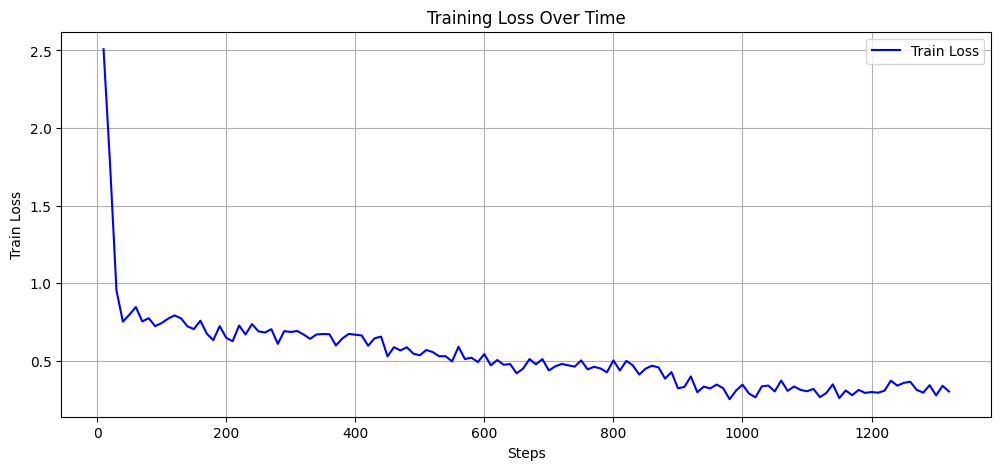

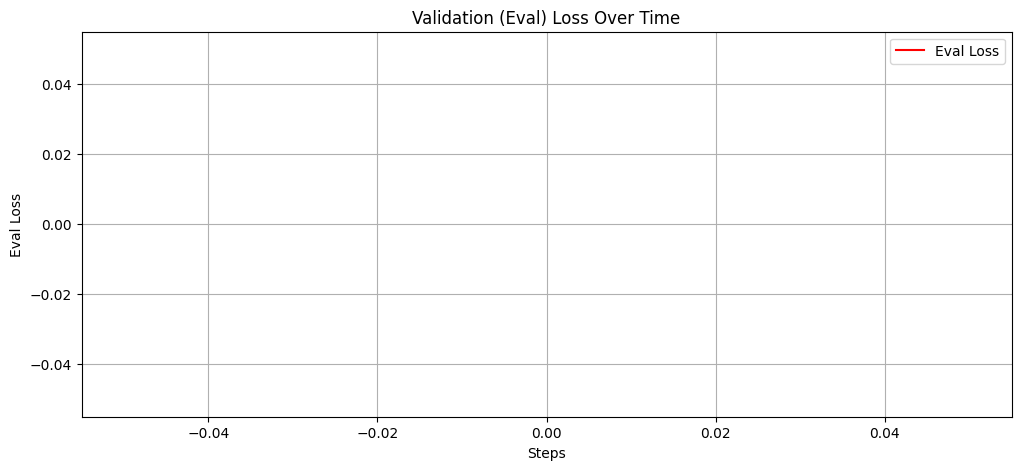

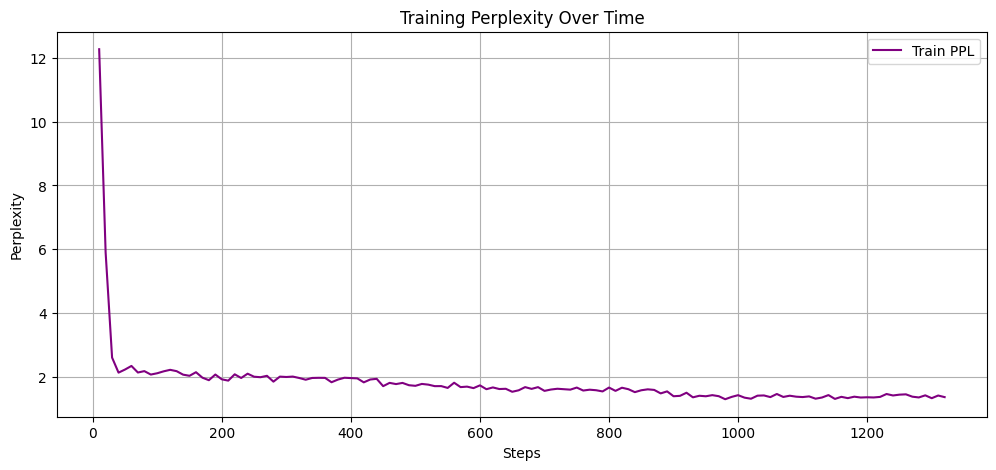

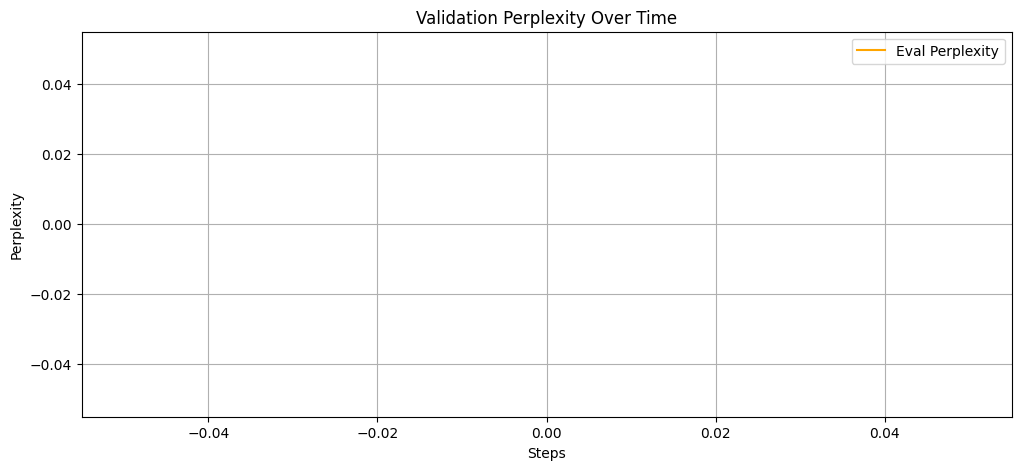

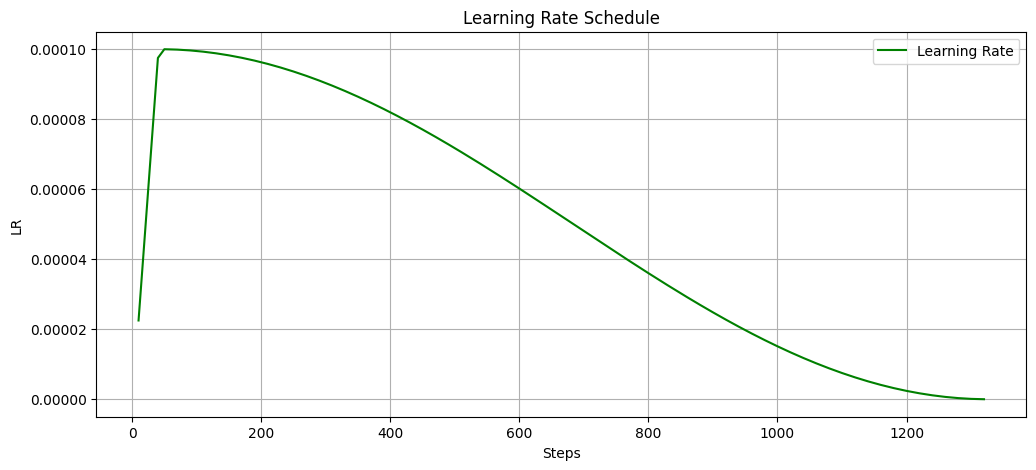


==================== ALL Logged Metrics ====================
{'epoch': 0.022643645626945937, 'grad_norm': 3.5652382373809814, 'learning_rate': 2.25e-05, 'loss': 2.5076, 'step': 10}
{'epoch': 0.04528729125389187, 'grad_norm': 2.579486608505249, 'learning_rate': 4.75e-05, 'loss': 1.7736, 'step': 20}
{'epoch': 0.06793093688083782, 'grad_norm': 0.8350196480751038, 'learning_rate': 7.25e-05, 'loss': 0.9537, 'step': 30}
{'epoch': 0.09057458250778375, 'grad_norm': 0.48046690225601196, 'learning_rate': 9.75e-05, 'loss': 0.7528, 'step': 40}
{'epoch': 0.11321822813472969, 'grad_norm': 0.5253650546073914, 'learning_rate': 9.998791559307701e-05, 'loss': 0.7974, 'step': 50}
{'epoch': 0.13586187376167563, 'grad_norm': 0.4876766502857208, 'learning_rate': 9.994614983388985e-05, 'loss': 0.8471, 'step': 60}
{'epoch': 0.15850551938862156, 'grad_norm': 0.5107350945472717, 'learning_rate': 9.987457845022766e-05, 'loss': 0.7545, 'step': 70}
{'epoch': 0.1811491650155675, 'grad_norm': 0.482820600271225, 'le

In [10]:
import json
import os
import math
import matplotlib.pyplot as plt

# =============================
# 1) Load trainer_state.json
# =============================

state_path = r"D:\AMIT\AOU PROJECT\AOU Graduation Project\AOU-Graduation-Project\BioIntellect\AI\fintune\fintuned_chating_model\phi_medical_lora_medical_chat_checkpoint\checkpoint-1326\trainer_state.json"

with open(state_path, "r") as f:
    state = json.load(f)

log_history = state["log_history"]

# =============================
# 2) Extract metrics
# =============================

steps = []
train_losses = []
train_ppl = []
learning_rates = []

eval_steps = []
eval_losses = []
eval_ppl = []

for e in log_history:
    # TRAIN LOSS
    if "loss" in e:
        steps.append(e["step"])
        train_losses.append(e["loss"])
        train_ppl.append(math.exp(e["loss"]))
        learning_rates.append(e.get("learning_rate", None))
        
    # EVAL LOSS
    if "eval_loss" in e:
        eval_steps.append(e["step"])
        eval_losses.append(e["eval_loss"])
        eval_ppl.append(math.exp(e["eval_loss"]))

# =============================
# 3) Plot TRAIN LOSS
# =============================

plt.figure(figsize=(12, 5))
plt.plot(steps, train_losses, label="Train Loss", color="blue")
plt.title("Training Loss Over Time")
plt.xlabel("Steps")
plt.ylabel("Train Loss")
plt.grid(True)
plt.legend()
plt.show()

# =============================
# 4) Plot EVAL LOSS
# =============================

plt.figure(figsize=(12, 5))
plt.plot(eval_steps, eval_losses, label="Eval Loss", color="red")
plt.title("Validation (Eval) Loss Over Time")
plt.xlabel("Steps")
plt.ylabel("Eval Loss")
plt.grid(True)
plt.legend()
plt.show()

# =============================
# 5) Plot TRAIN Perplexity
# =============================

plt.figure(figsize=(12, 5))
plt.plot(steps, train_ppl, label="Train PPL", color="purple")
plt.title("Training Perplexity Over Time")
plt.xlabel("Steps")
plt.ylabel("Perplexity")
plt.grid(True)
plt.legend()
plt.show()

# =============================
# 6) Plot EVAL Perplexity
# =============================

plt.figure(figsize=(12, 5))
plt.plot(eval_steps, eval_ppl, label="Eval Perplexity", color="orange")
plt.title("Validation Perplexity Over Time")
plt.xlabel("Steps")
plt.ylabel("Perplexity")
plt.grid(True)
plt.legend()
plt.show()

# =============================
# 7) Plot Learning Rate
# =============================

lr_steps = [s for s, lr in zip(steps, learning_rates) if lr is not None]
lr_values = [lr for lr in learning_rates if lr is not None]

plt.figure(figsize=(12, 5))
plt.plot(lr_steps, lr_values, color="green", label="Learning Rate")
plt.title("Learning Rate Schedule")
plt.xlabel("Steps")
plt.ylabel("LR")
plt.grid(True)
plt.legend()
plt.show()

# =============================
# 8) Print ALL metrics collected
# =============================

print("\n==================== ALL Logged Metrics ====================")
for log in log_history:
    print(log)
print("============================================================\n")